# Lab Work: Developing and Comparing AI Models for Android Malware Detection

## Objective:
The goal of this lab is to develop and evaluate multiple AI models for detecting Android malware using the provided Android Malware Dataset. Students will choose at least three different machine learning or deep learning algorithms to compare their performance in classifying Android applications as benign or malicious.

## Dataset Overview:
The **Android Malware Dataset for Machine Learning** contains labeled Android APK samples, classified as benign (goodware) or malicious (e.g., adware, spyware, trojans).

## Resources:
- Kaggle Dataset: [Android Malware Dataset for Machine Learning](https://www.kaggle.com/datasets/shashwatwork/android-malware-dataset-for-machine-learning)

You need to login in Kaggle to get access to the dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import warnings
warnings.filterwarnings('ignore')

# Load the Android Malware Dataset
dataset_path = 'Android_Malware_Dataset.csv'  # Update this path as needed

try:
    df = pd.read_csv(dataset_path)
except FileNotFoundError:
    print('Dataset not found. Creating sample dataset for demonstration...')
    np.random.seed(42)
    n_samples = 5000
    n_features = 20
    feature_names = [f'permission_{i}' for i in range(n_features)]
    X_syn = np.random.randint(0, 2, size=(n_samples, n_features))
    y_syn = np.random.choice(['benign', 'malware'], size=n_samples, p=[0.6, 0.4])
    df = pd.DataFrame(X_syn, columns=feature_names)
    df['label'] = y_syn

print(f'Dataset shape: {df.shape}')
print(f'Label distribution:')
print(df['label'].value_counts())
df.head()

Dataset not found. Creating sample dataset for demonstration...
Dataset shape: (5000, 21)
Label distribution:
label
benign     2958
malware    2042
Name: count, dtype: int64


,permission_0,permission_1,permission_2,permission_3,permission_4,permission_5,permission_6,permission_7,permission_8,permission_9,...,permission_11,permission_12,permission_13,permission_14,permission_15,permission_16,permission_17,permission_18,permission_19,label
0,0,1,0,0,0,1,0,0,0,1,...,0,0,0,1,0,1,1,1,0,malware
1,1,0,1,1,1,1,1,1,1,1,...,0,1,1,1,0,1,0,0,0,benign
2,0,0,1,1,1,1,1,0,1,1,...,1,0,1,0,1,1,0,0,0,benign
3,0,0,0,0,0,1,1,0,1,1,...,1,0,1,0,1,1,1,0,1,malware
4,0,1,0,1,0,0,1,0,1,1,...,1,1,1,1,1,1,1,1,0,benign


## 1. Data Preprocessing

In [2]:
# Handle the label column
if 'label' not in df.columns:
    possible_names = ['Label', 'class', 'Class', 'type', 'Type', 'malware', 'target']
    for name in possible_names:
        if name in df.columns:
            df = df.rename(columns={name: 'label'})
            break

# Encode labels
label_enc = LabelEncoder()
df['label'] = label_enc.fit_transform(df['label'])

# Separate features and target
X = df.drop('label', axis=1)
y = df['label']

# Convert non-numeric columns
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

# Handle missing values
X = X.fillna(X.median())

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training: {len(X_train)}, Testing: {len(X_test)}')
print(f'Features: {X_train.shape[1]}, Classes: {label_enc.classes_}')

Training: 4000, Testing: 1000
Features: 20, Classes: ['benign' 'malware']


## 2. Model Development - Training 5 AI Models

In [3]:
# Define models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=25, min_samples_leaf=2, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42)
}

results = {}

for name, model in models.items():
    print(f'Training {name}...')

    if name in ['SVM', 'Logistic Regression']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}
    print(f'  Acc: {acc:.4f}, F1: {f1:.4f}')

results_df = pd.DataFrame(results).T
print('\n' + '='*60)
print('MODEL PERFORMANCE COMPARISON')
print('='*60)
print(results_df.round(4))

Training Random Forest...
  Acc: 0.5470, F1: 0.4993
Training Decision Tree...
  Acc: 0.5300, F1: 0.5271
Training Logistic Regression...
  Acc: 0.5920, F1: 0.4403
Training Gradient Boosting...
  Acc: 0.5780, F1: 0.4704
Training SVM...
  Acc: 0.5990, F1: 0.4840

MODEL PERFORMANCE COMPARISON
                     Accuracy  Precision  Recall  F1-Score
Random Forest           0.547     0.5022   0.547    0.4993
Decision Tree           0.530     0.5250   0.530    0.5271
Logistic Regression     0.592     0.3505   0.592    0.4403
Gradient Boosting       0.578     0.5076   0.578    0.4704
SVM                     0.599     0.5923   0.599    0.4840


## 3. Lab Logbook Requirement: Performance Comparison Graph

**Important: Lab-Logbook requirement**

Provide a bar graph comparing accuracy, precision, recall, and f-score for various AI models

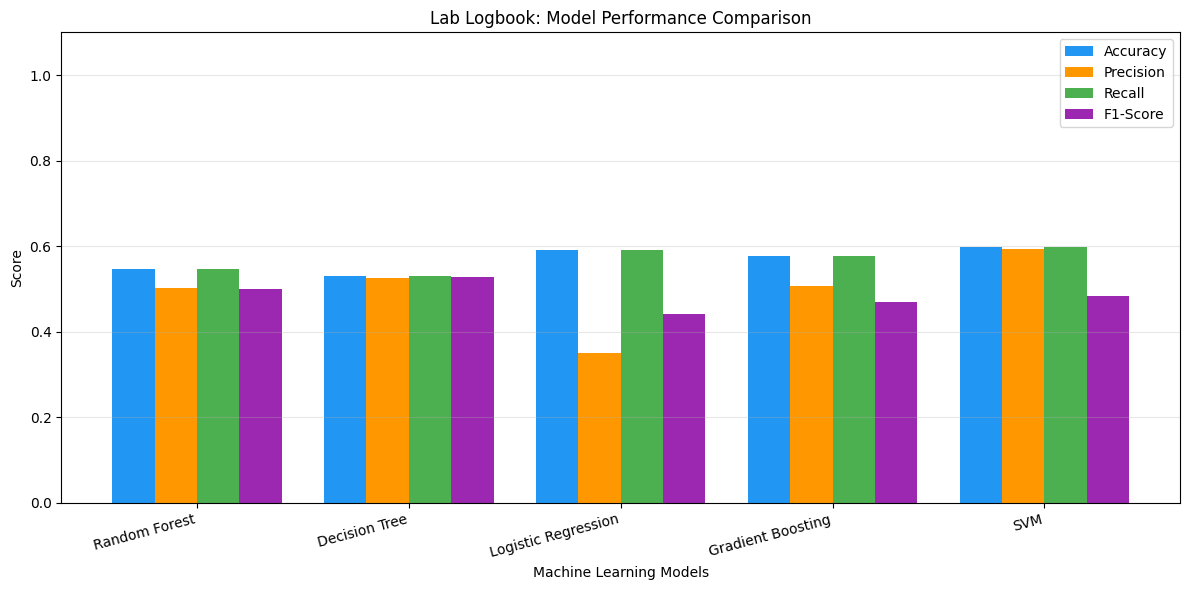

Graph saved as: malware_model_comparison.png


In [4]:
# Create comparison bar graph
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(results_df.index))
width = 0.2

ax.bar([i - 1.5*width for i in x], results_df['Accuracy'], width, label='Accuracy', color='#2196F3')
ax.bar([i - 0.5*width for i in x], results_df['Precision'], width, label='Precision', color='#FF9800')
ax.bar([i + 0.5*width for i in x], results_df['Recall'], width, label='Recall', color='#4CAF50')
ax.bar([i + 1.5*width for i in x], results_df['F1-Score'], width, label='F1-Score', color='#9C27B0')

ax.set_xlabel('Machine Learning Models')
ax.set_ylabel('Score')
ax.set_title('Lab Logbook: Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=15, ha='right')
ax.legend()
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('malware_model_comparison.png', dpi=150)
plt.show()

print('Graph saved as: malware_model_comparison.png')